# PS-S6E01: Neural Network

This notebook tackles the [**Playground Series – Season 6, Episode 1: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s6e1), a competition focused on predicting the exam score for a student, based on features describing the student, the exam, and the facility.

**Neural Networks (MLP)** offer a fundamentally different approach to tabular prediction compared to gradient boosting machines. While tree-based models partition data into discrete steps, Neural Networks operate as universal function approximators, learning smooth, continuous non-linear relationships between features. By utilizing Entity Embeddings for categorical variables, this model captures complex semantic relationships that ordinal or one-hot encoding might miss. This distinct "smooth" decision boundary provides high-value diversity to the ensemble, often correcting errors made by tree-based models in edge cases.
This notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S06E01: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e01-eda).

## Install Needed Packages

In [1]:
!pip install torch torchvision torchaudio


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import gc
import sys
import copy
import math
import random
import warnings

# --- Third-party
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e01_feature_engineering import FeatureFactory
from ps_s06e01_model_visualizer import ModelVisualizer
from ps_s06e01_experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'exam_score'

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [4]:
training_df = helper.read_training_dataset()

TRAINING DATASET

   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc        7.910            98.800              no   
1   1   18   other  diploma        4.950            94.800             yes   
2   2   20  female     b.sc        4.680            92.600             yes   
3   3   19    male     b.sc        2.000            49.500             yes   
4   4   23    male      bca        7.650            86.900             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0        4.900       average  online videos             low            easy   
1        4.700          poor     self-study          medium        moderate   
2        5.800          poor       coaching            high        moderate   
3        8.300       average    group study            high        moderate   
4        9.600          good     self-study            high            easy   

   exam_score  
0      78.300  
1     

## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_test_dataset()

TEST DATASET

       id  age  gender   course  study_hours  class_attendance  \
0  630000   24   other       ba        6.850            65.200   
1  630001   18    male  diploma        6.610            45.000   
2  630002   24  female   b.tech        6.600            98.500   
3  630003   24    male  diploma        3.030            66.300   
4  630004   20  female   b.tech        2.030            42.400   

  internet_access  sleep_hours sleep_quality study_method facility_rating  \
0             yes        5.200          poor  group study            high   
1              no        9.300          poor     coaching             low   
2             yes        6.200          good  group study          medium   
3             yes        5.700       average        mixed          medium   
4             yes        9.200       average     coaching             low   

  exam_difficulty  
0            easy  
1            easy  
2        moderate  
3        moderate  
4        moderate  


## Feature Engineering Strategy

We employ a custom `FeatureFactory` to transform the raw data into a numerical format optimized for gradient-based learning. Unlike Decision Trees, which are robust to outliers and categorical strings, **Neural Networks** require smooth, scaled, and dense numerical inputs to converge effectively.

We employ a custom `FeatureFactory` to inject domain-specific biases into the dataset. Tree-based models (like CatBoost) are excellent at finding split points but struggle with **interactions** (multiplying two features) and **spatial density** (clustering).

1.  **Log Transformation & Scaling:**
    * **Why:** Neural Networks rely on backpropagation and gradient descent. Features with extreme skew or outliers (like `study_hours`) can cause exploding gradients or saturate activation functions, stalling training.
    * **How:** We apply `np.log1p` to skewed continuous variables to "squash" outliers and scale inputs to a narrow range (e.g., -1 to 1) using `StandardScaler`, ensuring equal contribution to the loss function.

2.  **One-Hot Encoding:**
    * **Why:** Simple MLPs cannot interpret raw strings or ordinal integers effectively. Treating categories as numbers (0, 1, 2) introduces a false sense of order, while strings cause errors.
    * **How:** We convert categorical variables (e.g., `school_type`) into sparse binary vectors (0s and 1s), allowing the network to learn a distinct weight for every category presence.

3.  **Cyclical Encoding:**
    * **Why:** Time-based features like "Hours" are cyclical. In a standard linear view, Hour 23 is "far" from Hour 0. In reality, 11 PM is adjacent to midnight.
    * **How:** We map temporal features onto a circle using Sine and Cosine transformations, preserving the true temporal proximity of late-night and early-morning events.

4.  **Interaction Features:**
    * **Why:** While deep networks can theoretically learn complex interactions (like Multiplication) through hidden layers, it is computationally expensive and slow. Providing these relationships explicitly acts as a "shortcut" for the optimizer.
    * **How:** We calculate explicit domain ratios like `study_to_sleep_ratio` and `restoration_index` to feed these critical non-linear signals directly into the first layer.

In [6]:
# Define which strategies to use for the CatBoost model here:
fe_strategies = [
    'drop_id',
    'binning',           # Helps NN see "buckets" of behavior
    'log',               # Compresses outliers in skewed features
    'interactions',      # Explicit interactions help convergence
    'cyclical',          # Sine/Cosine for hours
    'manual_formula',    # Domain knowledge
    'ordinal_encoding',  # Ensures basic ordinal mapping.
    'gaussian_transform' # Forces bell curves on numerics.
]

In [7]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 12
New Feature Count: 38
     age  gender   course  study_hours  class_attendance internet_access  \
0  0.138  female     b.sc        5.199             1.818              no   
1 -0.934   other  diploma        0.308             1.205             yes   
2 -0.193  female     b.sc        0.208             1.002             yes   
3 -0.531    male     b.sc       -0.661            -1.098             yes   
4  0.879    male      bca        1.546             0.666             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0       -1.096       average  online videos             low            easy   
1       -1.242          poor     self-study          medium        moderate   
2       -0.554          poor       coaching            high        moderate   
3        0.515       average    group study            high        moderate   
4        1.432          good     self-study            high     

### Model Training: Deep Learning Strategy

For the final training, we use a **5-Fold Cross-Validation** loop designed specifically to stabilize the training of deep neural networks. unlike decision trees, Neural Networks are sensitive to initialization and can easily overfit if trained too long.

1.  **Standardization (Pre-Loop):**
    * **The Challenge**: Neural Networks use Gradient Descent. If one feature ranges from 0–1 (e.g., `sleep_quality`) and another from 0–100 (e.g., `exam_score`), the gradients will become unbalanced, causing the optimizer to zigzag and converge slowly.
    * **The Fix:** We apply `StandardScaler` to the entire dataset, centering every feature at Mean=0 and Variance=1. This ensures the loss landscape is spherical, allowing the **Adam** optimizer to find the minimum efficiently.
2.  **Adaptive Learning & Early Stopping:**
    * **The Risk**: Training for a fixed number of epochs (e.g., 100) is risky. Stop too early, and the model underfits; stop too late, and it memorizes the noise (overfitting).
    * **The Fix:** We implement two dynamic controls inside the loop:
        * **ReduceLROnPlateau:** If the validation score stalls, we automatically lower the learning rate (e.g., by 50%) to "fine-tune" the weights.
        * **Model Checkpointing:** We track the Validation RMSE at every epoch. At the end of the fold, we discard the final model state and **restore the weights** from the specific epoch that achieved the lowest error.

In [8]:
def prepare_inputs_for_nn(X_train, X_test, cat_features):
    """
    Separates data into Numerical (float) and Categorical (int) parts.
    Label Encodes categoricals to [0, N-1] for embeddings.
    """
    # Identify Numeric vs Categorical columns
    # We exclude the target 'exam_score' from this logic
    all_cols = X_train.columns.tolist()
    num_cols = [c for c in all_cols if c not in cat_features]
    
    X_train_cat = X_train[cat_features].copy()
    X_test_cat = X_test[cat_features].copy()
    
    # Label Encode Categoricals safely (Handle new categories in test)
    cat_dims = [] # Tuples of (num_unique, embedding_size)
    
    for col in cat_features:
        # Fill NaNs with a string "MISSING" to treat it as a category
        X_train_cat[col] = X_train_cat[col].astype(str).fillna("MISSING")
        X_test_cat[col] = X_test_cat[col].astype(str).fillna("MISSING")
        
        le = LabelEncoder()
        # Fit on both to ensure we capture all categories
        unique_vals = pd.concat([X_train_cat[col], X_test_cat[col]]).unique()
        le.fit(unique_vals)
        
        # Transform
        X_train_cat[col] = le.transform(X_train_cat[col])
        X_test_cat[col] = le.transform(X_test_cat[col])
        
        # Determine Embedding Size (Rule of thumb: min(50, (num_categories + 1) // 2))
        num_cats = len(unique_vals)
        emb_dim = min(50, (num_cats + 1) // 2)
        cat_dims.append((num_cats, emb_dim))
        
    # Prepare Numerics (Already Gaussian'd by FeatureFactory, just fill NaNs)
    X_train_num = X_train[num_cols].fillna(0).values
    X_test_num = X_test[num_cols].fillna(0).values
    
    return {
        'train_cat': X_train_cat.values.astype(np.int64),
        'train_num': X_train_num.astype(np.float32),
        'test_cat': X_test_cat.values.astype(np.int64),
        'test_num': X_test_num.astype(np.float32),
        'cat_dims': cat_dims,
        'num_dim': len(num_cols)
    }

In [9]:
# Identify categorical features manually (TODO: via helper)
cat_cols = [
    'gender', 'course', 'internet_access', 'sleep_quality', 
    'study_method', 'facility_rating', 'exam_difficulty',
    'class_attendance_class', 'sleep_hours_class', 'study_hours_class', 
#    'cluster_label' # If using clustering
]
# Ensure these exist in X_full (FeatureFactory might rename/drop them)
valid_cats = [c for c in cat_cols if c in X_full.columns]

data_package = prepare_inputs_for_nn(X_full, X_test, valid_cats)

In [10]:
class ResNetBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super(ResNetBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, input_dim),
            nn.BatchNorm1d(input_dim)
        )
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.block(x))


class TabularResNet(nn.Module):
    def __init__(self, num_dim, cat_dims, hidden_dim=512, dropout_rate=0.2, num_blocks=3):
        super(TabularResNet, self).__init__()
        
        # Embedding Layers for Categoricals
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_cats, emb_dim) 
            for num_cats, emb_dim in cat_dims
        ])
        
        # Calculate total input size after embeddings
        total_cat_dim = sum(emb_dim for _, emb_dim in cat_dims)
        combined_dim = num_dim + total_cat_dim
        
        # Input Projector
        self.input_layer = nn.Linear(combined_dim, hidden_dim)
        self.bn0 = nn.BatchNorm1d(hidden_dim)
        
        # Residual Blocks
        self.blocks = nn.ModuleList([
            ResNetBlock(hidden_dim, hidden_dim, dropout_rate) 
            for _ in range(num_blocks)
        ])
        
        # Output Head
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, x_num, x_cat):
        # x_num: [batch_size, num_dim]
        # x_cat: [batch_size, num_cats] (Integers)
        
        # Process Embeddings
        embedded_cats = []
        for i, emb_layer in enumerate(self.embeddings):
            # x_cat[:, i] grabs the column for the i-th categorical var
            embedded_cats.append(emb_layer(x_cat[:, i]))
        
        # Concatenate all embeddings + numericals
        # [batch, cat_dim_1] + [batch, cat_dim_2] ... + [batch, num_dim]
        x = torch.cat(embedded_cats + [x_num], dim=1)
        
        # Pass through network
        x = self.input_layer(x)
        x = self.bn0(x)
        
        for block in self.blocks:
            x = block(x)
            
        return self.output_head(x)

In [11]:
# Setup Device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 0.01
DROPOUT_RATE = 0.2

Training on: cuda


In [12]:
# Dataset Class to handle Dual Inputs
class TabularDataset(torch.utils.data.Dataset):
    def __init__(self, x_num, x_cat, y=None):
        self.x_num = torch.FloatTensor(x_num)
        self.x_cat = torch.LongTensor(x_cat)
        self.y = torch.FloatTensor(y).reshape(-1, 1) if y is not None else None
        
    def __len__(self):
        return len(self.x_num)
        
    def __getitem__(self, idx):
        if self.y is not None:
            return self.x_num[idx], self.x_cat[idx], self.y[idx]
        return self.x_num[idx], self.x_cat[idx]

In [13]:
# Setup Device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 0.01
WEIGHT_DECAY = 1e-4

# Training Setup
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)

oof_preds = np.zeros(len(X_full))
test_preds = np.zeros(len(X_test))
history = {'train_loss': [], 'val_rmse': [], 'lrs': []}
scores = []

print(f"Starting Training with {n_folds} folds...")

# Pre-convert test data to tensors to save time in the loop
# We chunk this if memory is an issue, but for this size, it's usually fine
X_test_cat_tensor = torch.LongTensor(data_package['test_cat']).to(device)
X_test_num_tensor = torch.FloatTensor(data_package['test_num']).to(device)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_full, y)):
    gc.collect()
    print(f"\n=== Fold {fold+1} ===")

# Slice the pre-prepared numpy arrays
    X_train_cat_fold = data_package['train_cat'][train_idx]
    X_val_cat_fold   = data_package['train_cat'][val_idx]
    
    X_train_num_fold = data_package['train_num'][train_idx]
    X_val_num_fold   = data_package['train_num'][val_idx]
    
    y_train_fold = y.iloc[train_idx].values
    y_val_fold   = y.iloc[val_idx].values
    
    # Target Transform (Log1p)
    y_train_trans = np.log1p(y_train_fold)
    # Validation Y does not need transform for metrics, but does for Loss if you calculate it
    y_val_trans = np.log1p(y_val_fold)
    
    # Datasets & Loaders
    train_ds = TabularDataset(X_train_num_fold, X_train_cat_fold, y_train_trans)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    # Prepare Validation Tensors (Full batch for fast inference)
    # Moving full validation set to GPU for speed (dataset is small enough)
    val_num_t = torch.FloatTensor(X_val_num_fold).to(device)
    val_cat_t = torch.LongTensor(X_val_cat_fold).to(device)    
    
    # Model Init
    model = TabularResNet(
        num_dim=data_package['num_dim'], 
        cat_dims=data_package['cat_dims']
    ).to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.MSELoss()

    # SCHEDULER: Using CosineAnnealingWarmRestarts
    # T_0=10 means it resets LR every 10 epochs
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

    # Early Stopping / Best Model Logic
    best_val_rmse = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0
    ES_PATIENCE = 15
    
    progress_bar = tqdm(range(EPOCHS), desc=f"Fold {fold+1}", leave=True)

    # Outer Loop: Epochs
    for epoch in progress_bar:
        model.train()
        running_loss = 0.0

        for batch_num, batch_cat, batch_y in train_loader:
            batch_num, batch_cat, batch_y = batch_num.to(device), batch_cat.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            # Pass both inputs
            preds = model(batch_num, batch_cat)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Step Scheduler (Cosine updates every batch usually, but epoch is fine for tabular)
        scheduler.step()
        
        # Validation Check (End of Epoch)
        model.eval()

        with torch.no_grad():
            # Pass BOTH numerical and categorical inputs
            val_preds_log = model(val_num_t, val_cat_t).cpu().numpy().ravel()
            
            # Inverse Transform for RMSE calculation
            val_preds = np.expm1(val_preds_log)
            val_rmse = np.sqrt(mean_squared_error(y_val_fold, val_preds))

        history['train_loss'].append(running_loss / len(train_loader))
        history['val_rmse'].append(val_rmse)
        history['lrs'].append(optimizer.param_groups[0]['lr'])

        # Save Best Model
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        # Update Progress Bar Text
        progress_bar.set_postfix({
            'loss': f"{running_loss/len(train_loader):.4f}",
            'val_rmse': f"{val_rmse:.4f}",
            'best': f"{best_val_rmse:.4f}"
        })
        
        if patience_counter >= ES_PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    # Final Inference for Fold using Best Weights
    model.load_state_dict(best_model_weights)
    model.eval()
    with torch.no_grad():
        # OOF Predictions
        oof_pred_log = model(val_num_t, val_cat_t).cpu().numpy().ravel()
        oof_preds[val_idx] = np.expm1(oof_pred_log)
        
        # Test Predictions
        test_pred_log = model(X_test_num_tensor, X_test_cat_tensor).cpu().numpy().ravel()
        test_preds += np.expm1(test_pred_log) / n_folds

    print(f"Fold {fold+1} Best RMSE: {best_val_rmse:.5f}")
    scores.append(best_val_rmse)
    
# Clip final predictions to valid range (0-100)
oof_preds = np.clip(oof_preds, 0, 100)
test_preds = np.clip(test_preds, 0, 100)

print(f"\nOverall CV RMSE: {np.mean(scores):.5f}")        

Training on: cuda
Starting Training with 5 folds...

=== Fold 1 ===


Fold 1:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 40
Fold 1 Best RMSE: 8.84809

=== Fold 2 ===


Fold 2:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 38
Fold 2 Best RMSE: 8.85051

=== Fold 3 ===


...

  Early stopping at epoch 25
Fold 3 Best RMSE: 8.86315

=== Fold 4 ===


Fold 4:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 41
Fold 4 Best RMSE: 8.81930

=== Fold 5 ===


Fold 5:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 25
Fold 5 Best RMSE: 8.86882

Overall CV RMSE: 8.84998


### Model Evaluation Theory

We evaluate the model using **RMSE (Root Mean Squared Error)**.

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

* **Why RMSE?** This competition metric penalizes large errors more heavily than small ones. Being off by 10 points on one student is worse than being off by 1 point on 10 students.
* **Prediction Clipping:** Since exam scores are bounded (likely 0 to 100), predicting -5 or 105 is physically impossible and hurts RMSE. We apply `np.clip(preds, 0, 100)` to force all predictions into the valid range, gaining a "free" improvement in score.

## Visualizing Model Performance
We use three key plots to diagnose the health of our regression model

### Cross-Validation Stability Analysis
We visualize the Root Mean Squared Error (RMSE) across all 5 validation folds to assess model stability.

* **Consistency:** A relatively flat line indicates the model is robust and generalizes well, regardless of how the data is split.

* **Variance:** Large spikes (e.g., Fold 3 is much worse than Fold 1) suggest the model is unstable or overfitting to specific subsets of the training data. This is often a warning sign that the model might fail on the Private Leaderboard.

We aim for both a **low mean RMSE** and **low variance** between folds.

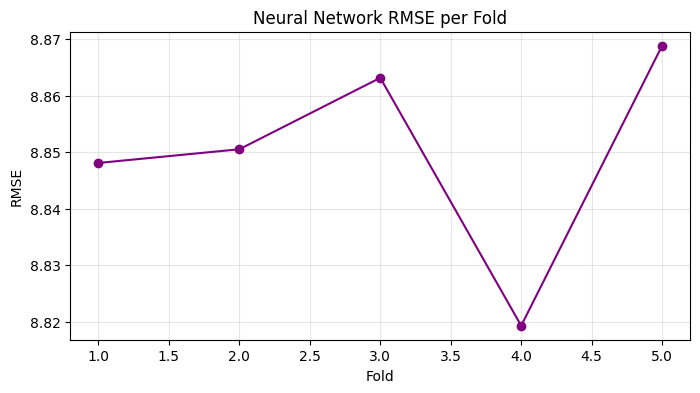

In [14]:
# Simple plot of the RMSE score for each fold
plt.figure(figsize=(8, 4))
plt.plot(range(1, n_folds+1), scores, marker='o', linestyle='-', color='purple')
plt.title("Neural Network RMSE per Fold")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.show()

### Prediction Error Plot (True vs. Predicted)
This scatter plot compares the **Actual Exam Scores** (X-axis) against what the model **Predicted** (Y-axis).
* **The Red Line:** This represents "Perfect Prediction."
* **Tight Cloud:** The closer the blue dots are to the red dashed line, the better the model.
* **Bias Detection:**
    * If dots at the bottom left (low scores) are consistently above the line, the model is over-predicting struggling students.
    * If dots at the top right (high scores) are below the line, the model is under-predicting top performers.

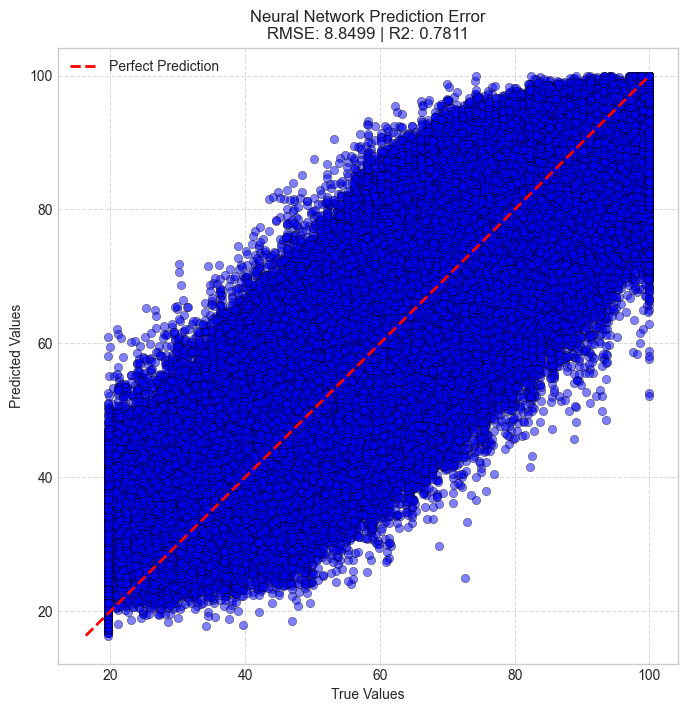

In [15]:
mviz = ModelVisualizer(model_name='Neural Network')

mviz.plot_prediction_error(y, oof_preds)

### Residual Plot
This plot shows the **Error** (True - Predicted) on the Y-axis against the **Predicted Score** on the X-axis.
* **The Goal:** You want a random cloud of points centered around the red line (0 error).
* **Bad Patterns:**
    * **Funnel Shape:** If the cloud gets wider as the score increases, the model is less certain about high-scoring students.
    * **U-Shape: If the points dip in the middle, the model is missing a non-linear relationship (e.g., it's fitting a straight line to a curved trend).
* **Outliers:** Dots that are very far from the center line represent students the model completely misjudged. Investigating these specific rows often reveals data quality issues.

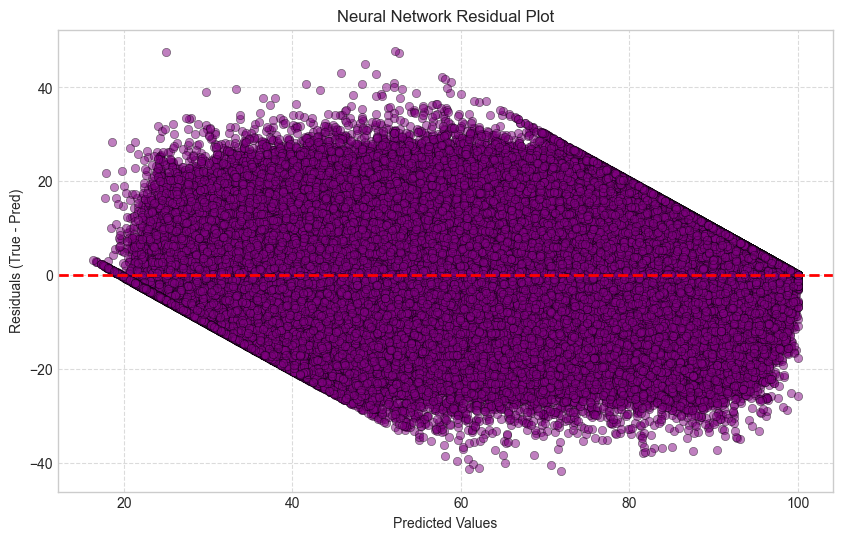

In [16]:
mviz.plot_residuals(y, oof_preds)

### Training Heartbeat

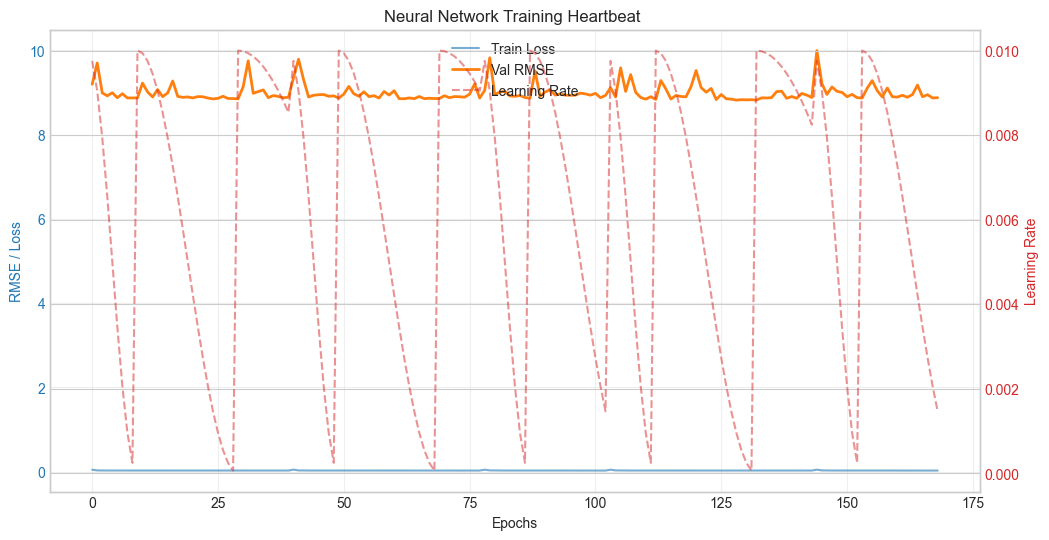

In [17]:
mviz.plot_training_heartbeat(history)

### Plot Distribution Mismatch

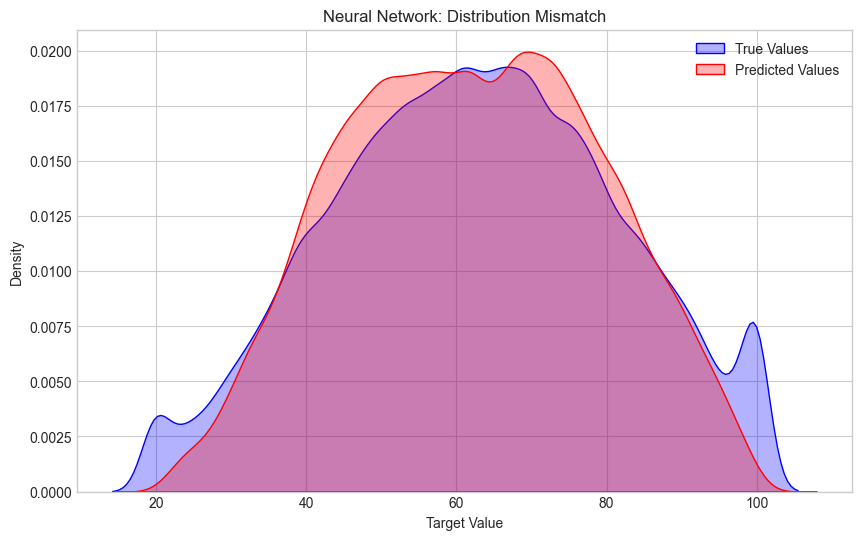

In [18]:
mviz.plot_distribution_mismatch(y_val_fold, val_preds) # Use the last fold's data

## Prepare Submission

In [19]:
submission_df = helper.read_sample_submission_dataset()
submission_df[TARGET] = test_preds

print('SAMPLE SUBMISSION')
print('=================')

print(submission_df.head(10))

SAMPLE SUBMISSION
       id  exam_score
0  630000      71.838
1  630001      68.995
2  630002      87.996
3  630003      54.400
4  630004      47.434
5  630005      71.748
6  630006      73.529
7  630007      58.120
8  630008      78.257
9  630009      91.580


In [20]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Predictions

The OOF and test predictions are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the predictions of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [21]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({'id': training_df.index, 'pred_nn': oof_preds, 'target': y})
oof_df.to_csv(f'{output_dir}/nn_oof_preds.csv', index=False)

test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_nn': test_preds})
test_pred_df.to_csv(f'{output_dir}/nn_test_preds.csv', index=False)

print(f'Saved for Blending: {output_dir}/nn_oof_preds.csv, {output_dir}/nn_test_preds.csv')

Saved for Blending: predictions/nn_oof_preds.csv, predictions/nn_test_preds.csv
